# Oppgave 4: Filtrering av lyd

RLC-kretser kan anvendes til å separere ut forskjellige frekvensbånd fra musikk. For eksempel kan det hende at man vil separere ut kun bass fra et lydsignal, og sende dette signalet til en subwoofer.

I denne oppgaven skal vi bruke python til å *simulere* en slik filtrereing. Nedenfor ser du pythonkode som vil laste inn og spille av en liten lydfil med opptak av perkusjon.

In [2]:
from scipy.io import wavfile
from IPython.display import Audio

fs, data = wavfile.read("RockDrums-48-mono-11secs.wav")
audioSignal = data*1.0 # convert to float

Audio(audioSignal, rate=fs)

Vi kan også studere innholdet i lydfilen ved å lage et plott av lydsignalet over tid:

Text(0.5, 0, 'Time $t$ (seconds)')

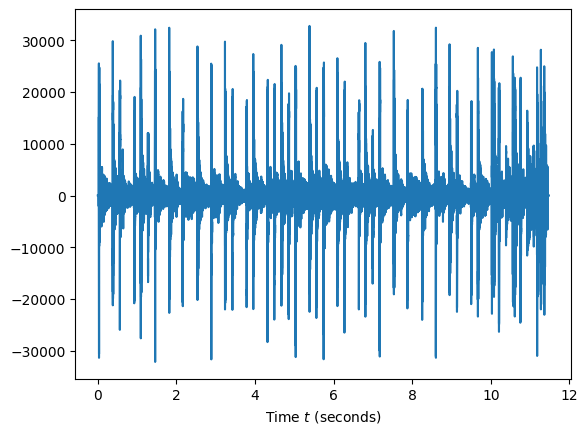

In [3]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt

time = np.linspace(0, (len(audioSignal)-1)/fs, len(audioSignal))
plt.plot(time, audioSignal)
plt.xlabel("Time $t$ (seconds)")

### Oppgave a)
* Bruk funksjonen `lsim` i modulen `scipy.signal` til å filtrere signalet `audioSignal` med bruk av transferfunksjonen $H(s)$ du fant i oppgave 2.
* Lytt til det filtrerte signalet og beskriv hva du hører, og sammenlign med bode-plottet til RLC-kretsen. Ser du en sammenheng? 

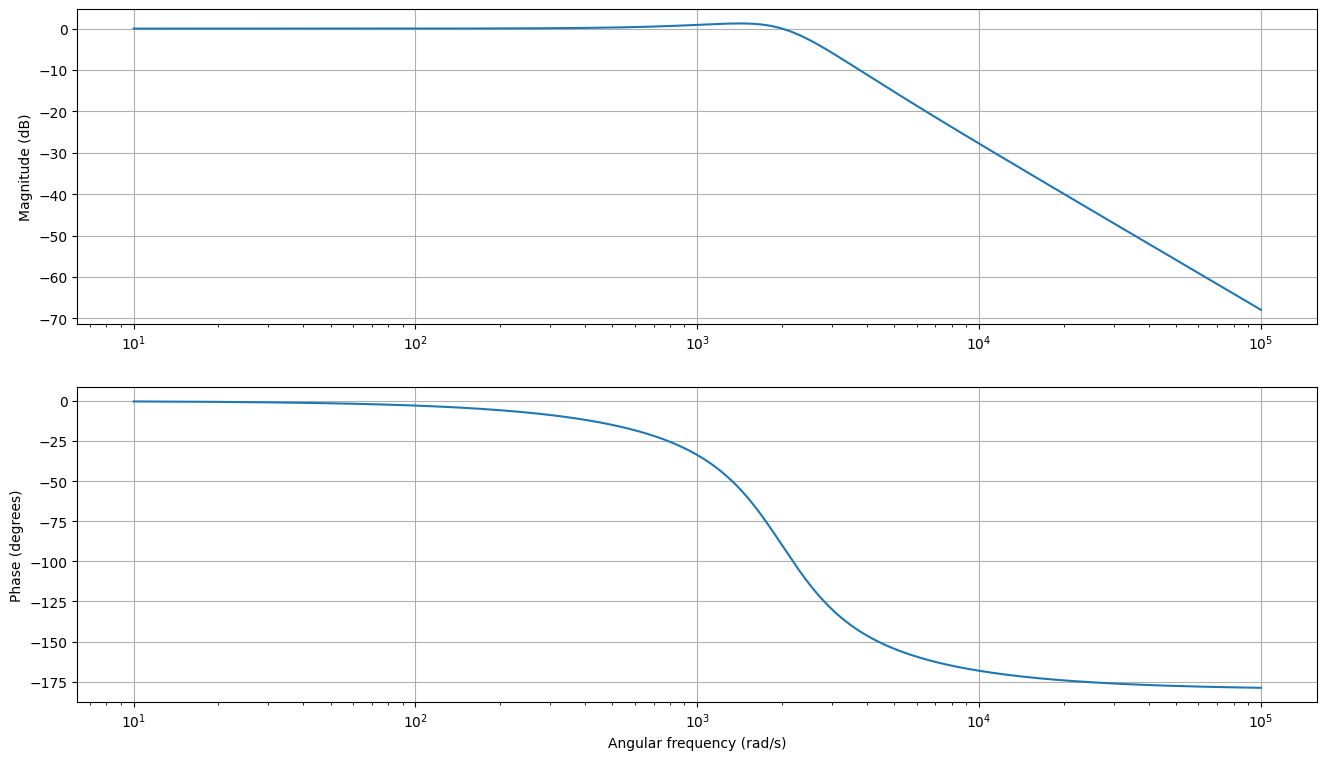

In [14]:
# Løsning!
R = 10 # Ohm
L = 5e-3 # Henry
C = 5e-5 # Farad

numerator = [1/(L*C)]
denominator = [1, R/L, 1/(L*C)]
system = sig.TransferFunction(numerator, denominator)

_, output, _ = sig.lsim(system, U=audioSignal, T=time)

w, mag, phase = sig.bode(system, w=np.logspace(1, 5, 501))
plt.figure(figsize=(16,9))
plt.subplot(2,1,1)
plt.semilogx(w, mag)
plt.grid(True)
plt.ylabel("Magnitude (dB)")
plt.subplot(2,1,2)
plt.semilogx(w, phase)
plt.grid(True)
plt.ylabel("Phase (degrees)")
plt.xlabel("Angular frequency (rad/s)")

Audio(output, rate=fs)

### Oppgave b)
* Regn ut transferfunksjonen til et nytt filter $H_2(s) = s^2\cdot L  C \cdot H(s)$, der $H(s)$ er transferfunksjonen til den seriekoblede RLC-kretsen vår.
* Lag et nytt systemobjekt for $H_2(s)$ i Python, og framstill bode-plottet til det nye systemet $H_2(s)$. 
* Gi en forklaring på hva som har skjedd med $H_2(s)$. Hvorfor viser bodeplottet det "motsatte" av $H(s)$?
    * *Hint: hvordan ser bode-plottet til $s^2\cdot (L \cdot C)^2$ ut, og hva skjer når du multipliserer to transferunksjoner?*
    
#### Teorisvar:
$$
\begin{align}
H_2(s) &= s^2 \cdot L C \cdot H(s) \\
&= s^2 \cdot L C \cdot \frac{\frac{1}{LC}}{s^2+\frac{R}{L} + \frac{1}{LC}} \\
&= \frac{s^2}{s^2+\frac{R}{L} + \frac{1}{LC}} 
\end{align}
$$
* Multiplikasjon av to komplekse funksjoner :
$$
\begin{align}
X(s)\cdot Y(s) &= \left(|X(s)|\cdot e^{j\angle X(s)}\right)\cdot \left(|X(s)|\cdot e^{j\angle Y(s)}\right) \\
&= |X(s)|\cdot |X(s)| \cdot e^{j(\angle X(s)+\angle Y(s))} 
\end{align}
$$
    Med andre ord summerer vi vinklene, og multipliserer absoluttverdiene. Videre vil omregning av absoluttverdi til decibel gi:
$$ 20\cdot \log_{10}\left(|X(s)|\cdot |X(s)|\right) = 20\cdot \log_{10}(|X(s)|) + 20\cdot \log_{10}(|Y(s)|)$$
    Kurvene i bode-plottet til $H_2(s)$ bør med andre ord være summen av kurvene i bode-plottene for $s^2\cdot LC$ og $H(s)$. Dette stemmer nokså bra med hva vi ser dersom vi studerer bode-plottene til alle de tre funksjonene.

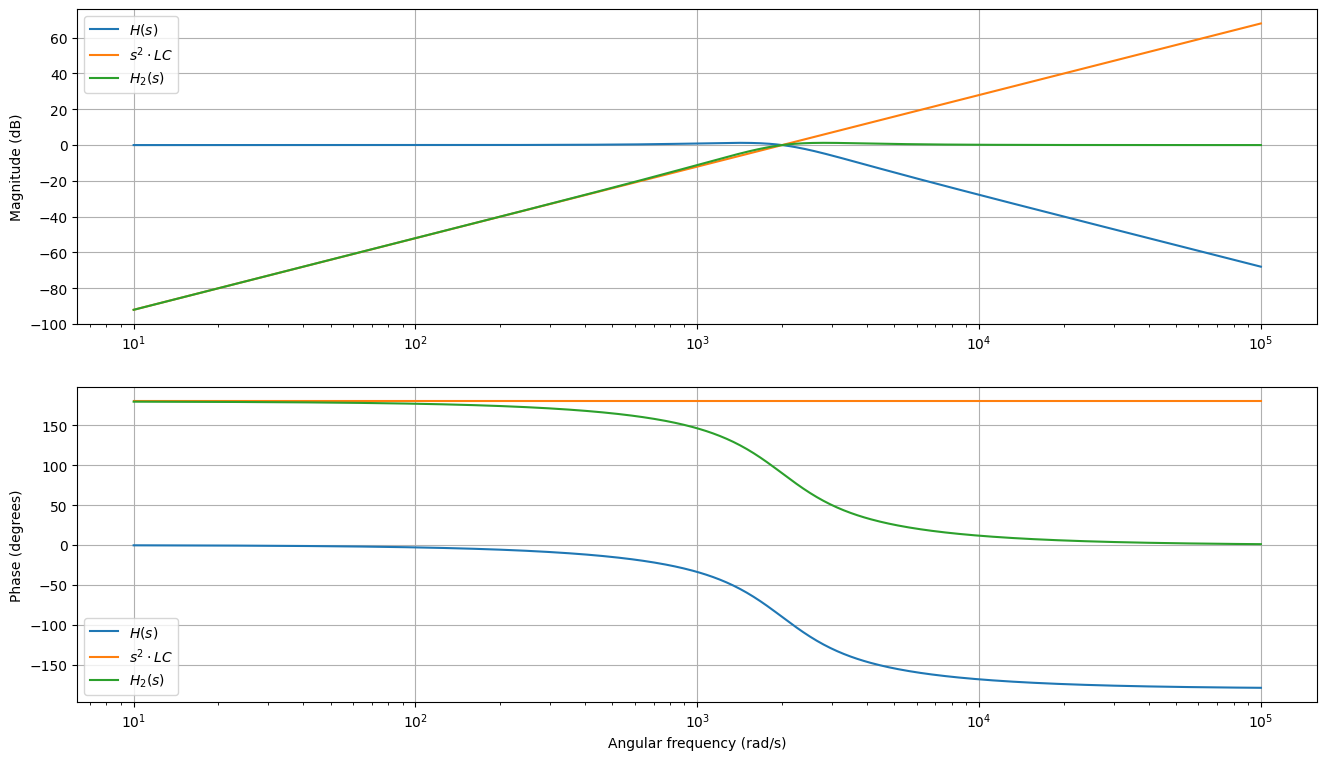

In [18]:
# Løsning!
R = 10 # Ohm
L = 5e-3 # Henry
C = 5e-5 # Farad

numerator = [1, 0, 0]
denominator = [1, R/L, 1/(L*C)]
system2 = sig.TransferFunction(numerator, denominator)



w, mag2, phase2 = sig.bode(system2, w=np.logspace(1, 5, 501))
s_squared = sig.TransferFunction([1*(L*C), 0, 0],[1])
w, mag_s_squared, phase_s_squared = sig.bode(s_squared, w=np.logspace(1, 5, 501))

plt.figure(figsize=(16,9))
plt.subplot(2,1,1)
plt.semilogx(w, mag, label=r'$H(s)$')
plt.semilogx(w, mag_s_squared, label=r"$s^2\cdot LC$")
plt.semilogx(w, mag2, label=r"$H_2(s)$")
plt.legend()
plt.grid(True)
plt.ylabel("Magnitude (dB)")
plt.subplot(2,1,2)
plt.semilogx(w, phase, label=r'$H(s)$')
plt.semilogx(w, phase_s_squared, label=r"$s^2\cdot LC$")
plt.semilogx(w, phase2, label=r"$H_2(s)$")
plt.legend()
plt.grid(True)
plt.ylabel("Phase (degrees)")
plt.xlabel("Angular frequency (rad/s)")

### Oppgave c)
* Bruk Python til å filtrere signalet `audioSignal` med bruk av den nye transferfunksjonen $H_2(s)$.
* Lytt til det nye filtrerte signalet. Hva er forskjellig fra orignalen?

In [19]:
# Løsning!
_, output, _ = sig.lsim(system2, U=audioSignal, T=time)
Audio(output, rate=fs)

# Når man lytter til lyden og sammenligner med den originale lydfilen er høres det ut som den filtrerte lyden er noe "tynnere". Dette stemmer ganske bra med at H_2(s) er et høypassfilter som vil dempe bass-elementene i musikken

### Oppgave d)

* Finn differensialligningen for filteret med transferfunksjonen $H_2(s)$
* Hvordan vil du omstrukturere RLC-kretsen for at den skal ha egenskapene til $H_2(s)$? Begrunn svaret

#### Teorisvar:
$$
\begin{align}
H_2(s) = \frac{V_{x}(s)}{V_0(s)} &= \frac{s^2}{s^2+\frac{R}{L}\cdot s + \frac{1}{LC}} \\
V_x(s)\cdot \left(s^2+\frac{R}{L}\cdot s + \frac{1}{LC}\right) &= V_0(s)\cdot s^2 \\
V_x(s)\cdot s^2 + V_x(s)\cdot \frac{R}{L}\cdot s + V_x(s)\cdot\frac{1}{LC}&= V_0(s)\cdot s^2 \\
V_x(s) + V_x(s)\cdot \frac{R}{L}\cdot \frac{1}{s} + V_x(s)\cdot\frac{1}{LC}\cdot \frac{1}{s^2}&= V_0(s) \\
\end{align}
$$
* Dersom vi substituerer $V_x(s)$ med $s\cdot L\cdot I(s)$, som er formelen for spenning over en spole, får vi:
$$
\begin{align}
s\cdot L\cdot I(s) + s\cdot L\cdot I(s)\cdot \frac{R}{L}\cdot \frac{1}{s} + s\cdot L\cdot I(s)\cdot\frac{1}{LC}\cdot \frac{1}{s^2}&= V_0(s) \\
s\cdot L\cdot I(s) + R\cdot I(s) + \frac{1}{s}\cdot\frac{1}{C}\cdot I(s)&= V_0(s) \\
\end{align}
$$
    som vi kjenner igjen som KVL-uttrykket til en seriekoblet RLC-krets. Dersom vi bytter om på spolen og kondensatoren i den seriekoblede RLC-kretsen, vil dette altså gi systemet beskrevet av $H_2(s)$.